# Lecture 23: Automatic differentiation with Pytorch
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PIMILab/ENGR1050/blob/main/notebooks/lec23.ipynb)


## Overview

In the last lecture, we showed how to optimize a function using Newton's method. We saw that *if we know how to compute the derivative of a function*, we can use Newton to find roots.

Today we will use Pytorch to learn how to automatically take derivatives of functions. Once we have that ingredient, we will have everything we need to minimize objectives that depend on complicated functions (like a neural network). Once you complete todays tutorial you will know enough to do some real machine learning next week.

In [1]:
# First, let's install and import PyTorch
import torch
print("PyTorch version:", torch.__version__)

# Check if PyTorch is working
test_tensor = torch.tensor([1.0, 2.0, 3.0])
print("Test tensor:", test_tensor)

PyTorch version: 2.8.0+cu126
Test tensor: tensor([1., 2., 3.])


# From lists, to numpy, to Pytorch tensors

Let's think back to how we have built up different types of data structures to hold numbers over the semester

- **Lists** let us traverse a bunch of numbers with for loops
- **Numpy arrays** could do everything that a list could do, but also let us perform linear algebra operations on it (dot product, scalar multiplication, etc)
- **Pytorch tensors** will allow us to do everything a Numpy array can do, but also build up a computational graph to compute gradients

The following shows how to create and work with a tensor. The syntax is nearly identical to a numpy array, but there are additional flags `requires_grad=True` that must be set if you want to take the derivative with respect to this variable. If you set that flag, Torch will track all downstream calculations that follow from the variable.

In [2]:
import torch

# Create scalars/0D-tensors with gradient tracking enabled
x = torch.tensor(3.0, requires_grad=True)
y = torch.tensor(4.0, requires_grad=True)
f = torch.exp(17 * torch.sin(x) + 4*y)

# Create a vector/1D-tensor with gradient tracking enabled
z = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

# Create a matrix without gradient tracking
A = torch.tensor([[1.0, 2.0], [3.0, 4.0]])  # Default requires_grad=False
B = torch.zeros((2, 3))                     # Default requires_grad=False



Much like numpy, torch has a number of helper functions, smart initializers, etc. To keep things from getting overwhelming I am going to only share the limited syntax that we'll need, but at the end of the unit I'll point you to resources if you want to learn torch in earnest.

For now, leave autocomplete on in Colab - if you write a comment about what you want to do before you start writing, it will help you find the command that you need.

```python
# generate a pytorch tensor initialized to [1,2] with gradient tracking on
__________ <--- see what colab autocompletes

In [5]:
torch.tensor([1, 2], dtype=torch.float32, requires_grad=True)

tensor([1., 2.], requires_grad=True)

In [ ]:
#TODO: Repeat exercise above

## Exercises: Basic tensor creation and derivatives

Like we showed in class, torch will create a computational graph tracking everything downstream from any tensor with `requires_grad=True`. The following gives an example of how to compute the gradient of a function $z = x^2 + 2$.

In [6]:
# Build a variable x and set requires_grad=True to track computation with it
x = torch.tensor(3.0, requires_grad=True)
print("x =", x)

# Add a single node of computational graph: y = x^2
y = x**2
print("y = x^2 =", y)

# Add a second node to the computational graph: z = y + 2
z = y + 2
print("z = y + 2 =", z)

# Compute the derivative dz/dx
z.backward()  # This computes the derivative
print("dz/dx at x=3:", x.grad)

# Mathematical check: if z = x^2 + 2, then dz/dx = 2x = 2*3 = 6 ✓

x = tensor(3., requires_grad=True)
y = x^2 = tensor(9., grad_fn=<PowBackward0>)
z = y + 2 = tensor(11., grad_fn=<AddBackward0>)
dz/dx at x=3: tensor(6.)


### Exercise 1: Check that you can accurately calculate a derivative

- Choose a function that is easy to take a derivative of by hand, like `sin`, `cos` or `exp`
- Write a function that takes a point x as input and evaluates the derivative using automatic differentiation
- Make a list of values to evaluate the derivative between 0 and 1.
- Plot the answer to check that you got what you should get.

In order to plot a pytorch tensor, we first have to convert it to a numpy tensor. To do this:
- Given a torch tensor on the computational graph, e.g.  `x = torch.tensor(7, requires_grad=True)`
- We take it off of the computational graph using `x.detach()`
- We can then convert it to numpy using `x.detach().numpy()`

There are lots of reasons to take a variable off of the graph. It may be that we want to do a complicated and expensive calculation with it, and we know that we won't care about any of the gradients that are associated with that computation, or it may just not make sense - for example when we visualize the prediction, it doesn't make sense to track gradients as the tensor passes through matplotlib to generate a plot.

**Hints:**
Use the following to get started:

```python
def getDerivativeOfSin(x):
    # Expects scalar pytorch tensor as input
    # TODO: put code here to calculate derivative with torch.backward

    return 0 # TODO: replace 0 with function to be returned

# Collect a list of derivative values and plot them
listOfValues = []
for i in range(20):
    # Get x input as a torch tensor
    x = i*(1.0/20)
    x_torch = torch.tensor(x, requires_grad=True)
    
    # Evaluate your function to compute derivative
    y_torch = getDerivativeOfSin(x_torch)

    # Convert to a number so we can plot
    y_number = y_torch.detach().numpy()

    # Put it into the list
    listOfValues.append(y_number)

# Generate a plot
import matplotlib.pyplot as plt
plt.plot(listOfValues)
```


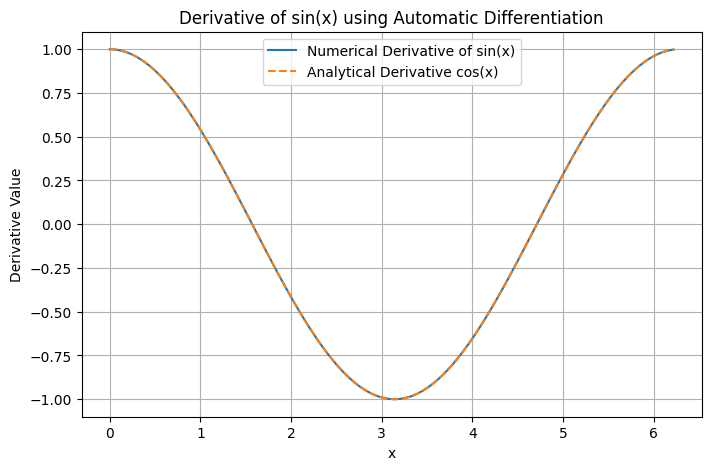

In [7]:
import torch
import matplotlib.pyplot as plt

def getDerivativeOfSin(x):
    # Expects scalar pytorch tensor as input
    y = torch.sin(x)
    y.backward() # This computes the derivative of y with respect to x
    return x.grad # Return the computed gradient

# Collect a list of derivative values and plot them
listOfValues = []
# We'll evaluate between 0 and 2*pi for a full sine cycle
num_points = 100
for i in range(num_points):
    x = i * (2 * torch.pi / num_points)
    x_torch = torch.tensor(x, requires_grad=True)

    # Evaluate your function to compute derivative
    y_torch_deriv = getDerivativeOfSin(x_torch)

    # Convert to a number so we can plot
    y_number = y_torch_deriv.detach().numpy()

    # Put it into the list
    listOfValues.append(y_number)

# Generate a plot
x_values_for_plot = [i * (2 * torch.pi / num_points) for i in range(num_points)]
plt.figure(figsize=(8, 5))
plt.plot(x_values_for_plot, listOfValues, label='Numerical Derivative of sin(x)')

# For comparison, plot the analytical derivative (cos(x))
cos_values = [torch.cos(torch.tensor(x)).item() for x in x_values_for_plot]
plt.plot(x_values_for_plot, cos_values, '--', label='Analytical Derivative cos(x)')

plt.xlabel('x')
plt.ylabel('Derivative Value')
plt.title('Derivative of sin(x) using Automatic Differentiation')
plt.legend()
plt.grid(True)
plt.show()

### Exercise 2: Checking solutions to ODEs

In the last section on ODEs, we checked that given function $u$ was a solution of an ODE $\dot{u} = f(u,t)$ by taking the derivative of the LHS and checking that it matched f.

Consider $u(t) = \exp - t$. Show that it is a solution of $u_t = - u$ by plugging in a few values of t using the code below.

**Note:** When you call `backward()`, backprop will aggregate gradients in variables (`t.grad` in the example below). Make sure to call

```python
# Example code to compute derivative of u = exp(-t)
t = torch.tensor(0.0, requires_grad=True)
u = torch.exp(-t)
u.backward()
print("du/dt at t=0:", t.grad)  
# zero out gradient for next calculation
t.grad.zero_()
```

In [17]:
values_of_t = [0.0, 1.0, 2.0]

print("Verifying du/dt = -u for u(t) = exp(-t)")
print("--------------------------------------")

for val_t in values_of_t:
    t = torch.tensor(val_t, requires_grad=True)
    u = torch.exp(-t)

    # Compute the derivative du/dt
    u.backward()

    print(f"For t = {val_t}:")
    print(f"  u = {u.item():.4f}")
    print(f"  du/dt = {t.grad.item():.4f}")
    print(f"  -u = {-u.item():.4f}")
    print("--------------------------------------")

    # Zero out gradient for next calculation to prevent accumulation
    t.grad.zero_()

Verifying du/dt = -u for u(t) = exp(-t)
--------------------------------------
For t = 0.0:
  u = 1.0000
  du/dt = -1.0000
  -u = -1.0000
--------------------------------------
For t = 1.0:
  u = 0.3679
  du/dt = -0.3679
  -u = -0.3679
--------------------------------------
For t = 2.0:
  u = 0.1353
  du/dt = -0.1353
  -u = -0.1353
--------------------------------------


# Introducing `modelClass` to define models that we will fit to data

That is really all you need to know in order to fit a model to data with gradient descent. The following `modelClass` will let us define any sort of model that you might want to fit to data. We'll start by doing something that should feel familiar - fitting a linear $y = a*x+b$ function to data. But we will be able to use this to fit much more complicated types of functions to data. At the end of the lecture, we will use this to fit a mechanical model for plastic deformation to experimental data. Next week, we will use the same thing to fit multilayer perceptrons to data.

The `modelClass` is pretty simple. It just needs an initializer that sets up whatever parameters need to be learned in the model (e.g. $a$ and $b$ in linear regression) and provide a `forward` function that evaluates the model on a given input `x`.

**Remember:** Methods like Newton or gradient descent depend crucially on how good of an initial guess you give them. You can easily get a different fit for the same data if you start with a different initial guess.

In [9]:
class modelClass:
    def __init__(self, a0, b0):
        # Initialize a linear model y = a*x + b
        # a0 - (float) initial value for slope
        # b0 - (float) initial value for intercept

        self.a = torch.tensor(a0, requires_grad=True)
        self.b = torch.tensor(b0, requires_grad=True)

    def forward(self, x):
        # Given input x (assumed to be a scalar shape torch tensor), return predicted y = a*x+b
        return self.a * x + self.b

# Example: Linear regression

To see how to fit a model to data, we will generate some *synthetic data* by adding noise to the function $y = 3.5 x + 2$.

When we fit a model of the form $y = a*x + b$ to this data, we will hope to recover $a = 3.5$, and $b = 2$.

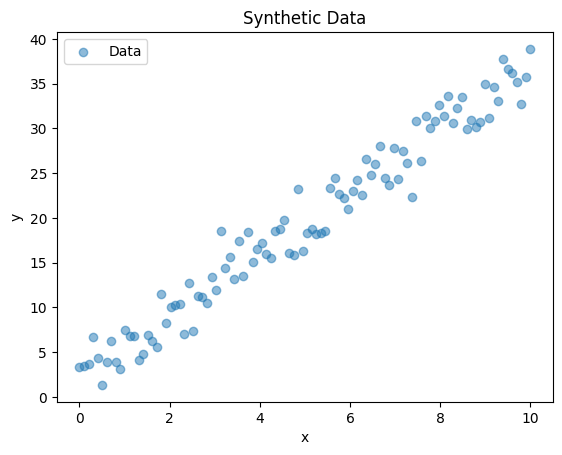

In [10]:
# Generate some synthetic data to fit a linear model to
import torch

x_data = torch.linspace(0, 10, steps=100)
y_data = 3.5 * x_data + 2.0 + torch.randn(x_data.size()) * 2.0  # y = 3.5x + 2 + noise

import matplotlib.pyplot as plt
plt.scatter(x_data.numpy(), y_data.numpy(), label='Data', alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic Data')
plt.legend()
plt.show()

The following code will train the model. It functions by:
- Initializing the model
- Setting parameters (`learning_rate` and how many steps to take)
- Taking a number of gradient descent steps
    - Take a forward pass seeing the error associated with the current guess for the model
    - Take the gradient of the error with respect to the model parameters
    - Use the gradients to update the current guess for the model parameters

This will steer the model at each step toward whatever little nudges drive the error down.

In [11]:
# Initialize a linear model with a = b = 0
model = modelClass(a0=0.0, b0=0.0)

# Set up loop to train model with gradient descent
learning_rate = 0.0001
num_steps = 200
for step in range(num_steps):

    # Step 1: Take forward pass by evaluating model on each data point and computing the total loss
    total_loss = 0.0
    for i in range(len(x_data)):
        x = x_data[i]
        y_true = y_data[i]

        # Forward pass: compute predicted y
        y_pred = model.forward(x)

        # Compute loss (mean squared error)
        loss = (y_pred - y_true)**2
        total_loss += loss.item()

    # Step 2: Backward pass: compute gradients using automatic differentiation
    loss.backward()

    # Step 3: Update parameters using gradient descent
    with torch.no_grad():
        model.a -= learning_rate * model.a.grad
        model.b -= learning_rate * model.b.grad

        # Zero gradients after updating - otherwise they will accumulate
        model.a.grad.zero_()
        model.b.grad.zero_()

    # Print out progress every 10 steps
    if step % 10 == 0:
        print(f"Step {step}, Total Loss: {total_loss/len(x_data)}, a: {model.a.item()}, b: {model.b.item()}")

Step 0, Total Loss: 487.15833670020106, a: 0.07774520665407181, b: 0.007774520665407181
Step 10, Total Loss: 321.27656977236273, a: 0.7738510370254517, b: 0.07738511264324188
Step 20, Total Loss: 211.80181014597417, a: 1.3414605855941772, b: 0.134146049618721
Step 30, Total Loss: 139.680392915532, a: 1.8042932748794556, b: 0.18042930960655212
Step 40, Total Loss: 92.27167374607875, a: 2.181689977645874, b: 0.21816900372505188
Step 50, Total Loss: 61.193695269189774, a: 2.489421844482422, b: 0.24894222617149353
Step 60, Total Loss: 40.89197993032634, a: 2.7403483390808105, b: 0.27403494715690613
Step 70, Total Loss: 27.688473409181316, a: 2.944956064224243, b: 0.29449567198753357
Step 80, Total Loss: 19.150084293947003, a: 3.1117944717407227, b: 0.311179518699646
Step 90, Total Loss: 13.66908671031939, a: 3.247835397720337, b: 0.3247836232185364
Step 100, Total Loss: 10.184720931882621, a: 3.358764171600342, b: 0.33587655425071716
Step 110, Total Loss: 7.998356688565109, a: 3.4492168426

We can now visualize the model.

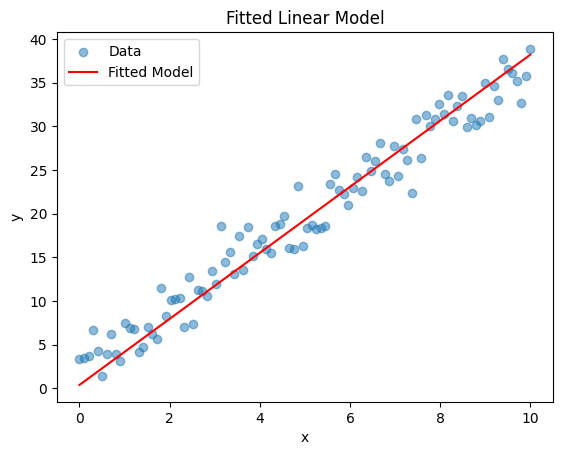

In [12]:
# Visualize the fitted model
plt.scatter(x_data.numpy(), y_data.numpy(), label='Data', alpha=0.5)
x_fit = torch.linspace(0, 10, steps=100)
y_fit = model.forward(x_fit)
plt.plot(x_fit.numpy(), y_fit.detach().numpy(), color='red', label='Fitted Model')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Fitted Linear Model')
plt.legend()
plt.show()

**Takeaway:** You can use this code to fit **a model of any kind** to data. You just need to:
- Modify the `ModelClass` if you want to fit something other than a linear regression to data.
- Change the forward pass if you want to give a different objective other than minimizing the sum of square errors.

### Your turn: polynomial regression

Modify the code above to generate synthetic data that looks like $y = x^3 + x - 1 + \text{noise}$.

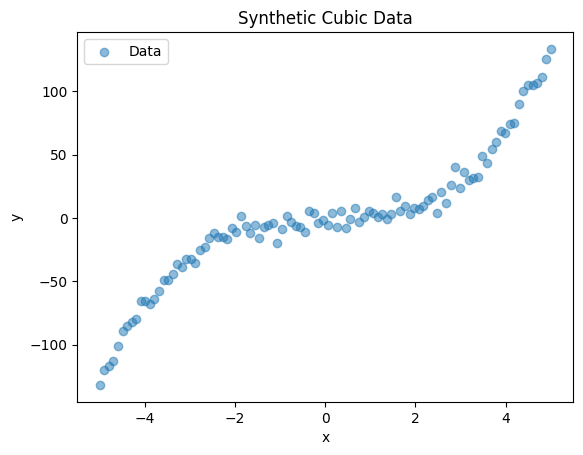

In [18]:
# Generate some synthetic data for a cubic model
import torch
import matplotlib.pyplot as plt

x_data = torch.linspace(-5, 5, steps=100) # Adjust range for cubic function
y_data = x_data**3 + x_data - 1.0 + torch.randn(x_data.size()) * 5.0 # y = x^3 + x - 1 + noise

plt.scatter(x_data.numpy(), y_data.numpy(), label='Data', alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic Cubic Data')
plt.legend()
plt.show()

\\:Modify the model so that instead of fitting a linear function, you fit something of the form $y = a*x^3 + b*x^2 + c*x +d$.

In [19]:
class CubicModel:
    def __init__(self, a0, b0, c0, d0):
        # Initialize a cubic model y = a*x^3 + b*x^2 + c*x + d
        self.a = torch.tensor(a0, requires_grad=True)
        self.b = torch.tensor(b0, requires_grad=True)
        self.c = torch.tensor(c0, requires_grad=True)
        self.d = torch.tensor(d0, requires_grad=True)

    def forward(self, x):
        # Given input x, return predicted y = a*x^3 + b*x^2 + c*x + d
        return self.a * x**3 + self.b * x**2 + self.c * x + self.d

# Using gradient descent to calibrate a material model to data

Back in the beginning of class, we processed some stress/strain data that came

---

from NIST. This gives us a nice engineering relevant model that we can use to show how easy it is to fit something more complicated than polynomials with gradient descent and automatic differentiation.

**Run the following code block to clean download and clean up the stress/strain dataset, just like we did in Lecture 4.**

3 curves loaded
First 5 [displacement_mm, force_kN] points of curve 1: [[-22.3829, -0.0061], [-22.3699, 0.0102], [-22.3829, 0.0134], [-22.3699, 0.0134], [-22.3667, 0.0134]]


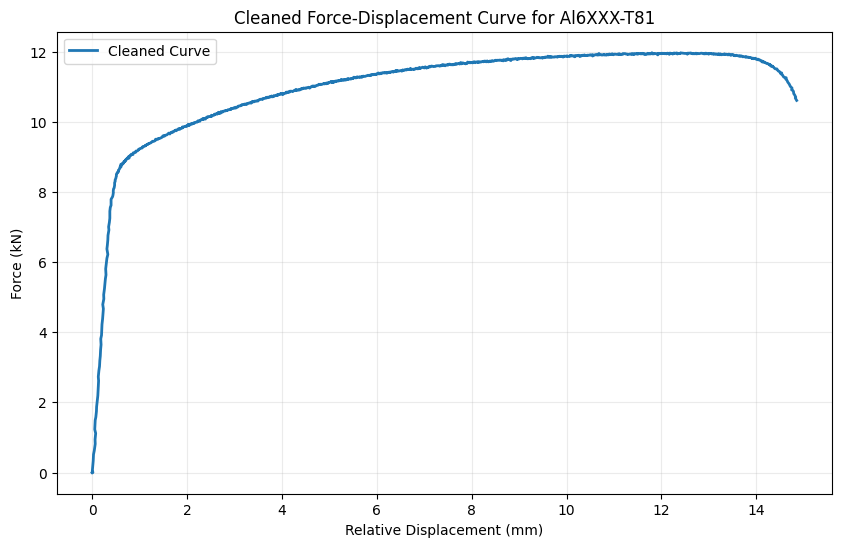

In [20]:
# We need some libraries to handle CSV files (the file format NIST used to store their data) and to download files from the internet
import csv
import urllib.request
import matplotlib.pyplot as plt
import os

# Create the 'Data' directory if it doesn't exist
os.makedirs('Data', exist_ok=True)

# NIST CSVs for the same material: AA6xxx-T81 sheet (three different orientations/repeats)
urls = [
    "https://data.nist.gov/od/ds/ark:/88434/mds2-2202/UniaxialTension/Al6xxx-T81/U15Al6XXX-T81_BatchB13R01T2.6921W12.71.csv",
    "https://data.nist.gov/od/ds/ark:/88434/mds2-2202/UniaxialTension/Al6xxx-T81/U30Al6XXX-T81_BatchB8R01T2.693W12.66.csv",
    "https://data.nist.gov/od/ds/ark:/88434/mds2-2202/UniaxialTension/Al6xxx-T81/U90Al6XXX-T81_BatchB5R03T2.684W12.68.csv",
]

# curves will be a list where each element is a list of [displacement_mm, force_kN] pairs
curves = []

# Loop over each URL, download the file, read the data, and store it in curves
for url in urls:
    local_name = 'Data/'+url.split("/")[-1]
    urllib.request.urlretrieve(url, local_name)  # download the file to the current directory

    # Read in the CSV file, appending each [displacement, force] pair as a new entry in the list
    data = []
    with open(local_name, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            # Columns per NIST spec: "Displacement_(mm)" and "Force_(kN)"
            d = float(row["Displacement_(mm)"])
            F = float(row["Force_(kN)"])
            data.append([d, F])
    curves.append(data)

# Curves is now a list of lists: 3 lists for each experiment, each containing [displacement, force] pairs
print(len(curves), "curves loaded")
print("First 5 [displacement_mm, force_kN] points of curve 1:", curves[0][:5])

# Clean the first curve to go through origin
firstEntry = curves[0][0]  # Get the first entry before the loop
cleanedCurve = []

for currentEntry in curves[0]:
    newDisplacement = currentEntry[0] - firstEntry[0]
    newEntry = [newDisplacement, currentEntry[1]]
    cleanedCurve.append(newEntry)

# generate plot of cleaned curve
plt.figure(figsize=(10, 6))
plt.plot([point[0] for point in cleanedCurve], [point[1] for point in cleanedCurve], label='Cleaned Curve', lw=2)
plt.xlabel('Relative Displacement (mm)')
plt.ylabel('Force (kN)')
plt.title('Cleaned Force-Displacement Curve for Al6XXX-T81')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

One of the simplest models for materials is the **linear strain-hardening model**. It assumes that when a material is stretched, there is a linear response (elastic region), before switching into plastic deformation and yielding. It is simple because it assumes both regions are linear.

The model is given by:

$$
F(\delta) = \begin{cases}
E \cdot \delta & \text{if } \delta < \delta_y \text{ (elastic region)} \\
F_y + H(\delta - \delta_y) & \text{if } \delta \geq \delta_y \text{ (plastic region)}
\end{cases}
$$

where:
- $E$ is the **elastic modulus** (slope in the elastic region)
- $\delta_y$ is the **yield displacement** (transition point between elastic and plastic)
- $H$ is the **hardening modulus** (slope in the plastic region)
- $F_y = E \cdot \delta_y$ is the **yield force** (force at which plastic deformation begins)

Our goal is to use gradient descent with PyTorch to find the parameters $E$, $\delta_y$, and $H$ that best fit the NIST aluminum tensile test data.

In [21]:
class StrainHardeningModel:
    def __init__(self, E0, delta_y0, H0):
        self.E = torch.tensor(E0, requires_grad=True)
        self.delta_y = torch.tensor(delta_y0, requires_grad=True)
        self.H = torch.tensor(H0, requires_grad=True)

    def forward(self, delta):
        F_y = self.E * self.delta_y

        # Compute both branches
        elastic_F = self.E * delta
        plastic_F = F_y + self.H * (delta - self.delta_y)

        F = elastic_F*(delta < self.delta_y) + plastic_F*(delta >= self.delta_y)

        return F

**Your job:** Play with the code below to find a good set of parameters (`E0`, `delta_y0`, `H0` and `learning_rate`) that let you match the data.

In [71]:
# Initialize model
model = StrainHardeningModel(E0=16.0, delta_y0=0.7, H0=0.04)

# Training parameters
learning_rate = 0.000001
num_steps = 1000

for step in range(num_steps):
    # Zero gradients at the start of each epoch
    if model.E.grad is not None:
        model.E.grad.zero_()
        model.delta_y.grad.zero_()
        model.H.grad.zero_()

    # Accumulate loss as a tensor
    total_loss = torch.tensor(0.0, requires_grad=True)

    for point in cleanedCurve:
        delta = torch.tensor(point[0], dtype=torch.float32)
        F_true = torch.tensor(point[1], dtype=torch.float32)

        # Forward pass
        F_pred = model.forward(delta)

        # Compute loss and add to total (keep as tensor)
        loss = (F_pred - F_true)**2
        total_loss = total_loss + loss

    # Now backward pass on the accumulated loss
    total_loss.backward()

    # Update parameters
    with torch.no_grad():
        model.E -= learning_rate * model.E.grad
        model.delta_y -= learning_rate * model.delta_y.grad
        model.H -= learning_rate * model.H.grad

    if step % 50 == 0:
        print(f"Step {step}, Avg Loss: {total_loss.item()/len(cleanedCurve):.4f}, E: {model.E.item():.2f}, delta_y: {model.delta_y.item():.4f}, H: {model.H.item():.2f}")

Step 0, Avg Loss: 0.5494, E: 16.00, delta_y: 0.6925, H: 0.04
Step 50, Avg Loss: 0.2640, E: 16.00, delta_y: 0.6425, H: 0.14
Step 100, Avg Loss: 0.2476, E: 16.00, delta_y: 0.6310, H: 0.16
Step 150, Avg Loss: 0.2466, E: 16.00, delta_y: 0.6282, H: 0.17
Step 200, Avg Loss: 0.2466, E: 16.00, delta_y: 0.6275, H: 0.17
Step 250, Avg Loss: 0.2465, E: 16.00, delta_y: 0.6273, H: 0.17
Step 300, Avg Loss: 0.2465, E: 16.00, delta_y: 0.6272, H: 0.17
Step 350, Avg Loss: 0.2465, E: 16.01, delta_y: 0.6272, H: 0.17
Step 400, Avg Loss: 0.2464, E: 16.01, delta_y: 0.6271, H: 0.17
Step 450, Avg Loss: 0.2464, E: 16.01, delta_y: 0.6271, H: 0.17
Step 500, Avg Loss: 0.2464, E: 16.01, delta_y: 0.6270, H: 0.17
Step 550, Avg Loss: 0.2464, E: 16.01, delta_y: 0.6270, H: 0.17
Step 600, Avg Loss: 0.2463, E: 16.01, delta_y: 0.6269, H: 0.17
Step 650, Avg Loss: 0.2463, E: 16.01, delta_y: 0.6269, H: 0.17
Step 700, Avg Loss: 0.2463, E: 16.01, delta_y: 0.6268, H: 0.17
Step 750, Avg Loss: 0.2462, E: 16.02, delta_y: 0.6268, H: 

After you train the model, the following will check your fit

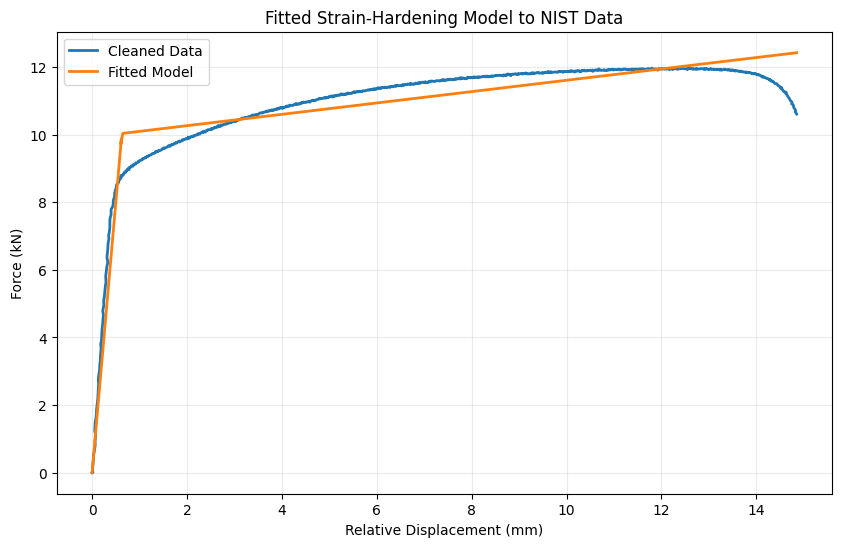

In [72]:
# Plot the fit model against the data
plt.figure(figsize=(10, 6))
# Plot cleaned data
plt.plot([point[0] for point in cleanedCurve], [point[1] for point in cleanedCurve], label='Cleaned Data', lw=2)
# Plot model prediction
delta_vals = [point[0] for point in cleanedCurve]
F_vals = [model.forward(torch.tensor(d, dtype=torch.float32)).item() for d in delta_vals]
plt.plot(delta_vals, F_vals, label='Fitted Model', lw=2)
plt.xlabel('Relative Displacement (mm)')
plt.ylabel('Force (kN)')
plt.title('Fitted Strain-Hardening Model to NIST Data')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Exercise:

Calibrate this model. You will find it to be far from "automatic". Suggestions:
- Set the number of iterations to zero and plot to see what the model is initialized to.
- Remember that gradient descent only works for "small enough" learning rate. This may be very small.
- Even with a small learning rate, you may land in different local minimum. Play with the initial guess and see how this effects your fit.
- You have a good answer when you get something that matches the elastic part (the first linear part to the left) and does a reasonably good job at the plastic part.

# Submit today's work
Today's assignment will be completed individually to make sure we all understand the basic moving pieces of PyTorch.

Submit to Canvas using the following [link](https://canvas.upenn.edu/courses/1881448/assignments/14088991).